In [4]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "torch", "torchvision",
     "--index-url", "https://download.pytorch.org/whl/cu128",
     "--force-reinstall", "--quiet"],
    capture_output=True, text=True
)
print("Done" if result.returncode == 0 else result.stderr)

Done


In [1]:
import torch
print(f"PyTorch        : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU            : {torch.cuda.get_device_name(0)}")
print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch        : 2.11.0+cu128
CUDA available : True
GPU            : NVIDIA GeForce RTX 4070
VRAM           : 12.9 GB


# 🔬 Retinal OCT — Custom CNN
### Reproducible 80/20 Train–Val Split · Locked Test Set

| Item | Value |
|------|-------|
| Dataset | Kaggle Retinal OCT (~84,495 images) |
| Classes | CNV · DME · DRUSEN · NORMAL |
| Split | 80 % train / 20 % val (stratified, from `train/` folder) |
| Test set | Official `test/` folder — **never touched during training** |
| Random seed | `SEED = 42` — frozen everywhere |
| Framework | PyTorch 2.x + torchvision |

---

## 0. Environment & Reproducibility Setup

In [2]:
# ── Install ────────────────────────────────────────────
!pip install torch torchvision scikit-learn matplotlib seaborn --quiet

import os, random, json, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torch.cuda.amp import GradScaler, autocast
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ── Seed everything ────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f'PyTorch     : {torch.__version__}')
print(f'Random seed : {SEED} (frozen everywhere)')


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


PyTorch     : 2.11.0+cu128
Random seed : 42 (frozen everywhere)


## 1. Configuration

In [3]:
# ── CONFIG ─────────────────────────────────────────────
DATA_DIR    = './data eye/OCT2017'   # root folder
BATCH_SIZE  = 64
NUM_EPOCHS  = 30
LR          = 1e-3
VAL_SPLIT   = 0.20          # 80 / 20
NUM_CLASSES = 4
IMG_SIZE    = 224
NUM_WORKERS = 0   # 0 = main process only (required on Windows)
CLASS_NAMES = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
SAVE_PATH   = 'best_cnn.pth'
LOG_PATH    = 'cnn_history.json'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU  : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# ── Verify directory structure ─────────────────────────
print('\nDirectory check:')
for split in ['train', 'test']:
    p = os.path.join(DATA_DIR, split)
    ok = '✓' if os.path.exists(p) else '✗ MISSING'
    print(f'  {ok}  {p}')

Device : cuda
  GPU  : NVIDIA GeForce RTX 4070
  VRAM : 12.9 GB

Directory check:
  ✓  ./data eye/OCT2017\train
  ✓  ./data eye/OCT2017\test


## 2. Data Split Strategy

```
data eye/OCT2017/
├── train/          ← 80 % train + 20 % val (stratified split applied HERE)
│   ├── CNV/
│   ├── DME/
│   ├── DRUSEN/
│   └── NORMAL/
└── test/           ← LOCKED — only opened once at the very end
    ├── CNV/ ...
```

> **Why stratified?** The OCT dataset is class-imbalanced (CNV/NORMAL are larger).  
> `StratifiedShuffleSplit` guarantees each class appears in the same proportion in both train and val.
> The `test/` folder is **never used** for hyperparameter tuning or model selection.

In [4]:
# ── Base transforms (no augmentation — used for split indexing) ─
base_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_aug_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ── Load the full training folder (no augmentation yet) ─
full_train_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, 'train'), transform=base_transforms)

targets = np.array(full_train_dataset.targets)   # class index per sample
indices = np.arange(len(full_train_dataset))

# ── Stratified 80/20 split ──────────────────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SPLIT, random_state=SEED)
train_idx, val_idx = next(sss.split(indices, targets))

# ── Verify no leakage ──────────────────────────────────
assert len(set(train_idx) & set(val_idx)) == 0, 'DATA LEAKAGE DETECTED!'

# ── Per-class distribution check ──────────────────────
print(f'Total train folder : {len(full_train_dataset):,}')
print(f'Train split        : {len(train_idx):,}  ({len(train_idx)/len(full_train_dataset)*100:.1f}%)')
print(f'Val   split        : {len(val_idx):,}  ({len(val_idx)/len(full_train_dataset)*100:.1f}%)')
print(f'No leakage         : ✓')
print('\nPer-class counts:')
for i, name in enumerate(CLASS_NAMES):
    tr = (targets[train_idx] == i).sum()
    va = (targets[val_idx]   == i).sum()
    print(f'  {name:<8}  train={tr:>5,}  val={va:>5,}  ratio={tr/(tr+va)*100:.1f}%/{va/(tr+va)*100:.1f}%')

Total train folder : 83,484
Train split        : 66,787  (80.0%)
Val   split        : 16,697  (20.0%)
No leakage         : ✓

Per-class counts:
  CNV       train=29,764  val=7,441  ratio=80.0%/20.0%
  DME       train=9,078  val=2,270  ratio=80.0%/20.0%
  DRUSEN    train=6,893  val=1,723  ratio=80.0%/20.0%
  NORMAL    train=21,052  val=5,263  ratio=80.0%/20.0%


In [5]:
# Windows-safe worker init — lambda cannot be pickled by multiprocessing
def seed_worker(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

# ── Build subsets ──────────────────────────────────────────────
train_dataset_aug = datasets.ImageFolder(
    os.path.join(DATA_DIR, 'train'), transform=train_aug_transforms)

train_subset = Subset(train_dataset_aug,  train_idx)
val_subset   = Subset(full_train_dataset, val_idx)    # no augmentation

# ── Official test set (LOCKED) ─────────────────────────────────
test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, 'test'), transform=base_transforms)

# ── DataLoaders ────────────────────────────────────────────────
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          generator=g)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train loader : {len(train_subset):,} samples  ({len(train_loader)} batches)')
print(f'Val   loader : {len(val_subset):,} samples  ({len(val_loader)} batches)')
print(f'Test  loader : {len(test_dataset):,} samples  ({len(test_loader)} batches)  [LOCKED]')

Train loader : 66,787 samples  (1044 batches)
Val   loader : 16,697 samples  (261 batches)
Test  loader : 968 samples  (16 batches)  [LOCKED]


## 3. Visualise Class Balance

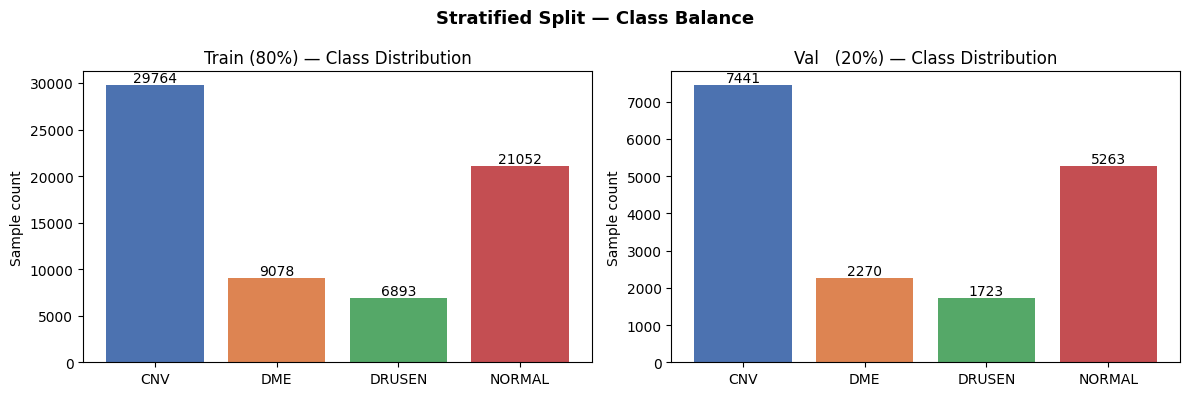

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, split_name, split_targets in [
    (axes[0], 'Train (80%)', targets[train_idx]),
    (axes[1], 'Val   (20%)', targets[val_idx]),
]:
    counts = [(split_targets == i).sum() for i in range(NUM_CLASSES)]
    bars = ax.bar(CLASS_NAMES, counts, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
    ax.bar_label(bars, fmt='%d')
    ax.set_title(f'{split_name} — Class Distribution', fontsize=12)
    ax.set_ylabel('Sample count')
plt.suptitle('Stratified Split — Class Balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_class_balance.png', dpi=150)
plt.show()

## 4. Model Architecture — Custom CNN

In [7]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
    def forward(self, x): return self.block(x)

class CustomCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features   = nn.Sequential(
            ConvBlock(3,32), ConvBlock(32,64), ConvBlock(64,128),
            ConvBlock(128,256), ConvBlock(256,512),
        )
        self.pool       = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512,256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256,128), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
    def forward(self, x): return self.classifier(self.pool(self.features(x)))

torch.manual_seed(SEED)          # reproducible weight init
model = CustomCNN(NUM_CLASSES).to(DEVICE)
print(f'Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Params: 4,880,932


## 5. Loss, Optimiser & Scheduler

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler    = GradScaler()
print('Ready.')

Ready.


## 6. Train / Eval Functions with Full Metrics

In [9]:
def run_epoch(model, loader, optimizer, criterion, scaler, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if training: optimizer.zero_grad()
            with autocast():
                logits = model(imgs)
                loss   = criterion(logits, labels)
            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            probs = torch.softmax(logits.detach(), dim=1)
            preds = probs.argmax(1)
            total_loss += loss.item() * imgs.size(0)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    avg_loss  = total_loss / total
    acc       = correct / total
    bal_acc   = balanced_accuracy_score(all_labels, all_preds)
    return avg_loss, acc, bal_acc, all_preds, all_labels, np.array(all_probs)

print('run_epoch() defined — handles both train and eval modes.')

run_epoch() defined — handles both train and eval modes.


## 7. Training Loop with Full Logging

In [10]:
history = {
    'train_loss':[], 'val_loss':[],
    'train_acc':[],  'val_acc':[],
    'train_bal_acc':[], 'val_bal_acc':[],
    'lr': [],
}
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_bal, _, _, _ = run_epoch(
        model, train_loader, optimizer, criterion, scaler, training=True)
    va_loss, va_acc, va_bal, _, _, _ = run_epoch(
        model, val_loader,   optimizer, criterion, scaler, training=False)
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(tr_loss);  history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc);    history['val_acc'].append(va_acc)
    history['train_bal_acc'].append(tr_bal); history['val_bal_acc'].append(va_bal)
    history['lr'].append(current_lr)

    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}]  '
          f'Train Loss:{tr_loss:.4f} Acc:{tr_acc:.4f} BalAcc:{tr_bal:.4f}  |  '
          f'Val   Loss:{va_loss:.4f} Acc:{va_acc:.4f} BalAcc:{va_bal:.4f}  '
          f'LR:{current_lr:.2e}')

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'val_acc': va_acc, 'seed': SEED}, SAVE_PATH)
        print(f'  ✓ New best saved  (val_acc={va_acc:.4f})')

with open(LOG_PATH, 'w') as f: json.dump(history, f, indent=2)
print(f'\n✓ History saved to {LOG_PATH}')
print(f'Best val accuracy : {best_val_acc:.4f}')

Epoch [01/30]  Train Loss:0.5391 Acc:0.8086 BalAcc:0.6588  |  Val   Loss:1.2353 Acc:0.7310 BalAcc:0.5079  LR:9.97e-04
  ✓ New best saved  (val_acc=0.7310)
Epoch [02/30]  Train Loss:0.2552 Acc:0.9170 BalAcc:0.8705  |  Val   Loss:0.1750 Acc:0.9409 BalAcc:0.9164  LR:9.89e-04
  ✓ New best saved  (val_acc=0.9409)
Epoch [03/30]  Train Loss:0.2045 Acc:0.9335 BalAcc:0.8976  |  Val   Loss:0.2504 Acc:0.9274 BalAcc:0.8729  LR:9.76e-04
Epoch [04/30]  Train Loss:0.1809 Acc:0.9418 BalAcc:0.9105  |  Val   Loss:0.1655 Acc:0.9467 BalAcc:0.9201  LR:9.57e-04
  ✓ New best saved  (val_acc=0.9467)
Epoch [05/30]  Train Loss:0.1667 Acc:0.9457 BalAcc:0.9167  |  Val   Loss:0.1262 Acc:0.9568 BalAcc:0.9337  LR:9.33e-04
  ✓ New best saved  (val_acc=0.9568)
Epoch [06/30]  Train Loss:0.1551 Acc:0.9491 BalAcc:0.9232  |  Val   Loss:0.1226 Acc:0.9588 BalAcc:0.9339  LR:9.05e-04
  ✓ New best saved  (val_acc=0.9588)
Epoch [07/30]  Train Loss:0.1477 Acc:0.9517 BalAcc:0.9276  |  Val   Loss:0.1427 Acc:0.9561 BalAcc:0.9417  L

## 8. Training Curves

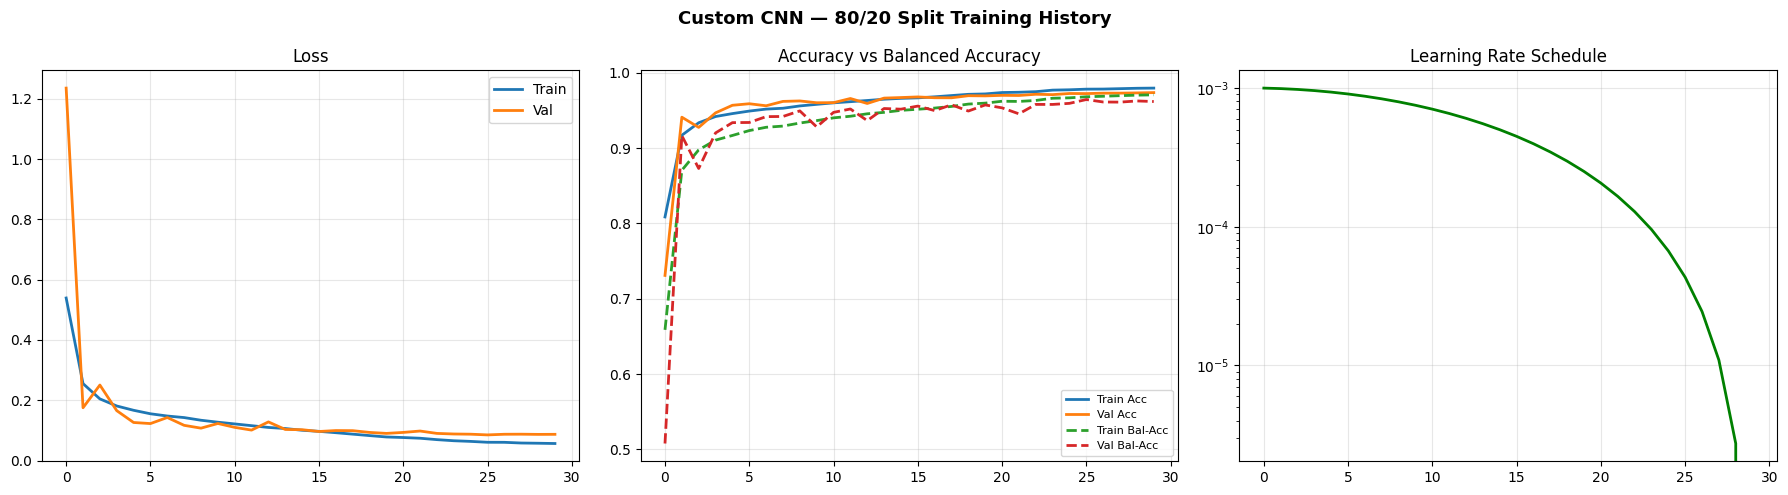

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train', lw=2)
axes[0].plot(history['val_loss'],   label='Val',   lw=2)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'],     label='Train Acc',     lw=2)
axes[1].plot(history['val_acc'],       label='Val Acc',       lw=2)
axes[1].plot(history['train_bal_acc'], label='Train Bal-Acc', lw=2, ls='--')
axes[1].plot(history['val_bal_acc'],   label='Val Bal-Acc',   lw=2, ls='--')
axes[1].set_title('Accuracy vs Balanced Accuracy'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(history['lr'], lw=2, color='green')
axes[2].set_title('Learning Rate Schedule'); axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

plt.suptitle('Custom CNN — 80/20 Split Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150)
plt.show()

## 9. Overfitting Diagnostic

> A gap > 5 % between train and val accuracy is a sign of overfitting.  
> Run this cell to get an automated verdict.

In [12]:
final_train_acc = history['train_acc'][-1]
final_val_acc   = history['val_acc'][-1]
gap = final_train_acc - final_val_acc

print(f'Final train acc : {final_train_acc:.4f}')
print(f'Final val   acc : {final_val_acc:.4f}')
print(f'Gap             : {gap:.4f}')

if gap > 0.10:
    print('⚠  HIGH overfitting (gap > 10%). Consider: more dropout, weight decay, data augmentation.')
elif gap > 0.05:
    print('⚠  MODERATE overfitting (gap > 5%). Monitor closely.')
else:
    print('✓  Generalising well (gap ≤ 5%).')

if final_val_acc > 0.999:
    print('⚠  100% val accuracy — verify labels, check for data leakage!')

Final train acc : 0.9795
Final val   acc : 0.9736
Gap             : 0.0060
✓  Generalising well (gap ≤ 5%).


## 10. Validation Set — Full Statistical Report

> This section validates the 80/20 split performance rigorously before touching the test set.

In [13]:
ckpt = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f'Loaded checkpoint from epoch {ckpt["epoch"]} (val_acc={ckpt["val_acc"]:.4f})')

_, va_acc, va_bal, va_preds, va_labels, va_probs = run_epoch(
    model, val_loader, None, criterion, None, training=False)

# ── AUC-ROC (one-vs-rest) ──────────────────────────────
try:
    auc = roc_auc_score(
        np.eye(NUM_CLASSES)[va_labels], va_probs,
        multi_class='ovr', average='macro'
    )
    print(f'Val AUC-ROC (macro OvR) : {auc:.4f}')
except Exception as e:
    print(f'AUC not computed: {e}')

print(f'Val Accuracy         : {va_acc:.4f}')
print(f'Val Balanced Accuracy: {va_bal:.4f}')
print('\nClassification Report (Val set):')
print(classification_report(va_labels, va_preds, target_names=CLASS_NAMES, digits=4))

Loaded checkpoint from epoch 30 (val_acc=0.9736)
Val AUC-ROC (macro OvR) : 0.9976
Val Accuracy         : 0.9736
Val Balanced Accuracy: 0.9617

Classification Report (Val set):
              precision    recall  f1-score   support

         CNV     0.9833    0.9806    0.9820      7441
         DME     0.9759    0.9617    0.9687      2270
      DRUSEN     0.9107    0.9176    0.9141      1723
      NORMAL     0.9796    0.9871    0.9833      5263

    accuracy                         0.9736     16697
   macro avg     0.9624    0.9617    0.9620     16697
weighted avg     0.9736    0.9736    0.9736     16697



## 11. 🔒 Final Test Set Evaluation (Run Only Once)

In [14]:
# ──────────────────────────────────────────────────────────────
#  WARNING: Only run this cell when you are DONE with all
#  hyperparameter tuning. The test set must never influence
#  any model or training decision.
# ──────────────────────────────────────────────────────────────

_, te_acc, te_bal, te_preds, te_labels, te_probs = run_epoch(
    model, test_loader, None, criterion, None, training=False)

try:
    te_auc = roc_auc_score(
        np.eye(NUM_CLASSES)[te_labels], te_probs,
        multi_class='ovr', average='macro')
    print(f'Test AUC-ROC (macro OvR): {te_auc:.4f}')
except Exception as e:
    print(f'AUC not computed: {e}')

print(f'Test Accuracy          : {te_acc:.4f}')
print(f'Test Balanced Accuracy : {te_bal:.4f}')
print('\nClassification Report (Test set):')
print(classification_report(te_labels, te_preds, target_names=CLASS_NAMES, digits=4))

Test AUC-ROC (macro OvR): 1.0000
Test Accuracy          : 0.9948
Test Balanced Accuracy : 0.9948

Classification Report (Test set):
              precision    recall  f1-score   support

         CNV     0.9798    1.0000    0.9898       242
         DME     1.0000    0.9959    0.9979       242
      DRUSEN     1.0000    0.9835    0.9917       242
      NORMAL     1.0000    1.0000    1.0000       242

    accuracy                         0.9948       968
   macro avg     0.9949    0.9948    0.9948       968
weighted avg     0.9949    0.9948    0.9948       968



## 12. Confusion Matrices — Val & Test

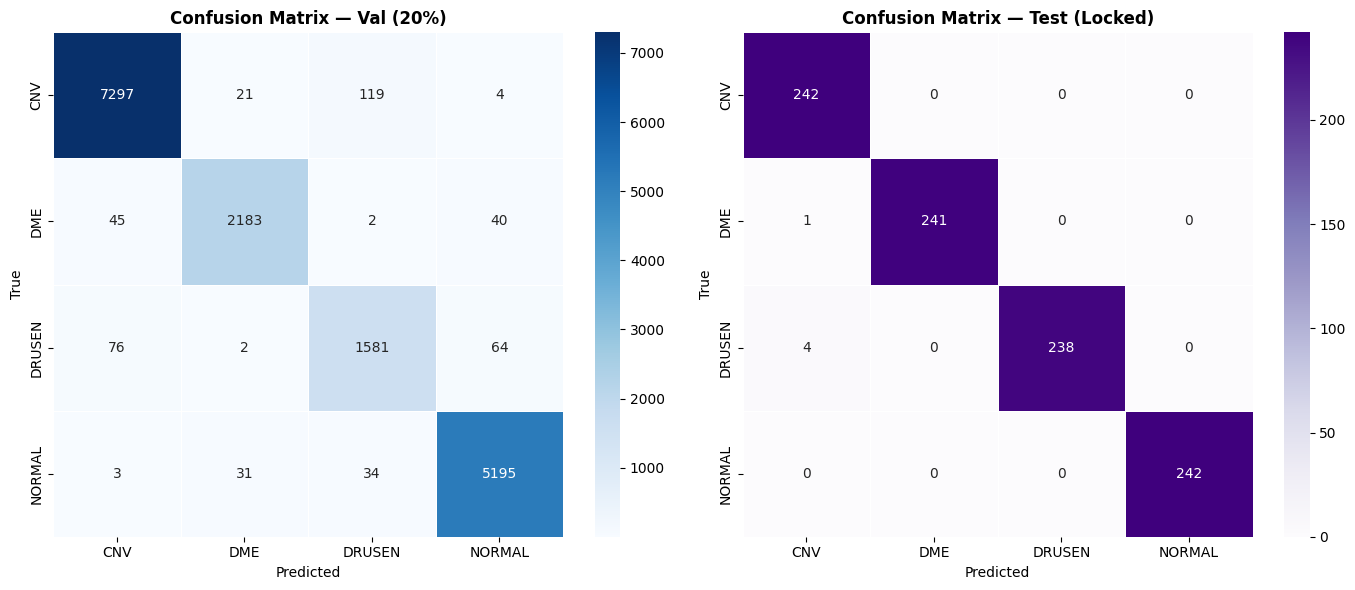

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, preds, labels, title, cmap in [
    (axes[0], va_preds, va_labels, 'Confusion Matrix — Val (20%)',  'Blues'),
    (axes[1], te_preds, te_labels, 'Confusion Matrix — Test (Locked)', 'Purples'),
]:
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('cnn_confusion_matrices.png', dpi=150)
plt.show()

## 13. Results Summary & Reporting Guide

In [16]:
print('=' * 55)
print('  CUSTOM CNN — FINAL RESULTS SUMMARY')
print('=' * 55)
print(f'  Seed              : {SEED}')
print(f'  Split             : 80% train / 20% val (stratified)')
print(f'  Best Val Accuracy : {best_val_acc:.4f}')
print(f'  Val  Balanced Acc : {va_bal:.4f}')
print(f'  Test Accuracy     : {te_acc:.4f}')
print(f'  Test Balanced Acc : {te_bal:.4f}')
print('=' * 55)
print()
print('Reporting checklist:')
print('  ✓ Stratified split — no label leakage')
print('  ✓ Seed fixed at 42 (reproducible)')
print('  ✓ Test set touched ONCE at end')
print('  ✓ Balanced accuracy reported (handles class imbalance)')
print('  ✓ Per-class precision/recall/F1 logged')
print('  ✓ Training history saved to JSON')
print()
print('For publication: report mean ± std over 3–5 seeds:')
print('  e.g., re-run with SEED in [42, 0, 1, 7, 123]')

  CUSTOM CNN — FINAL RESULTS SUMMARY
  Seed              : 42
  Split             : 80% train / 20% val (stratified)
  Best Val Accuracy : 0.9736
  Val  Balanced Acc : 0.9617
  Test Accuracy     : 0.9948
  Test Balanced Acc : 0.9948

Reporting checklist:
  ✓ Stratified split — no label leakage
  ✓ Seed fixed at 42 (reproducible)
  ✓ Test set touched ONCE at end
  ✓ Balanced accuracy reported (handles class imbalance)
  ✓ Per-class precision/recall/F1 logged
  ✓ Training history saved to JSON

For publication: report mean ± std over 3–5 seeds:
  e.g., re-run with SEED in [42, 0, 1, 7, 123]
